In [1]:
from sqlalchemy import create_engine, text
import pandas as pd
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from warnings import filterwarnings
filterwarnings('ignore')

In [2]:
engine = create_engine(
    f"mysql+mysqlconnector://{os.environ['DB_USER']}:{os.environ['DB_PASSWORD']}@{os.environ['DB_HOST']}/{os.environ['DB_NAME']}"
)

with engine.connect() as conn:
    result = conn.execute(text("SHOW TABLES"))
    tables = [row[0] for row in result]

print("Total Tables:", len(tables))
print("Table Names:")
for table in tables:
    print("-", table)

Total Tables: 2
Table Names:
- apple_products_pricing_2020_2026
- clean_dataset


In [3]:
for table in tables:
       print(f"\n Table: {table}")
       query = text(f"SELECT * FROM {table}")
       df = pd.read_sql_query(query, engine)
       display(pd.read_sql(f"SELECT * FROM {table} LIMIT 5", engine))


 Table: apple_products_pricing_2020_2026


,Date,Platform,Product_Category,Model_Name,Condition,Launch_Price_USD,Launch_Price_INR,Current_Price_USD,Current_Price_INR,Discount_Pct,Sale_Event,Stock_Status,Rating,Reviews_Count
0,2020-09-19,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,42042,435.81,43322.4,-1.6,,In Stock,4.7,40
1,2020-09-20,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,42042,436.49,42320.4,-1.7,,Out of Stock,4.6,84
2,2020-09-23,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,422.73,40879.4,1.5,,In Stock,4.4,110
3,2020-09-23,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,425.00,42008.7,0.9,,In Stock,4.8,111
4,2020-09-24,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,436.22,41984.3,-1.7,,In Stock,4.7,35



 Table: clean_dataset


,date,platform,product_category,model_name,condition,launch_price_usd,launch_price_inr,current_price_usd,current_price_inr,discount_pct,sale_event,stock_status,rating,reviews_count,year,month
0,2020-09-19,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,42042,435.81,43322.4,-1.6,No Sale Event,In Stock,4.7,40,2020,9
1,2020-09-20,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,42042,436.49,42320.4,-1.7,No Sale Event,Out of Stock,4.6,84,2020,9
2,2020-09-23,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,422.73,40879.4,1.5,No Sale Event,In Stock,4.4,110,2020,9
3,2020-09-23,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,425.00,42008.7,0.9,No Sale Event,In Stock,4.8,111,2020,9
4,2020-09-24,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,436.22,41984.3,-1.7,No Sale Event,In Stock,4.7,35,2020,9


In [4]:
df = pd.read_sql_query(text("SELECT * FROM clean_dataset"), engine)

In [5]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
date,80000,2024-09-14 22:14:06.359999744,2020-09-19 00:00:00,2023-11-03 00:00:00,2024-12-22 00:00:00,2025-10-27 00:00:00,2026-07-31 00:00:00,NaN
launch_price_usd,80000.0,963.959125,329.0,599.0,799.0,1199.0,1999.0,470.086413
launch_price_inr,80000.0,94467.99425,32242.0,58702.0,78302.0,117502.0,195902.0,46068.468464
current_price_usd,80000.0,782.769855,109.93,432.93,699.74,989.1125,2038.97,461.67397
current_price_inr,80000.0,74628.342369,9157.68,41686.825,67324.05,96568.125,203669.0,45117.872002
discount_pct,80000.0,21.418826,-2.0,6.7,21.3,36.8,73.1,16.69731
rating,80000.0,4.450099,3.8,4.3,4.4,4.7,4.9,0.269782
reviews_count,80000.0,2405.995925,10.0,896.0,1893.5,3383.0,11526.0,1973.630852
year,80000.0,2024.216225,2020.0,2023.0,2024.0,2025.0,2026.0,1.405657
month,80000.0,6.401112,1.0,3.0,6.0,10.0,12.0,3.46496


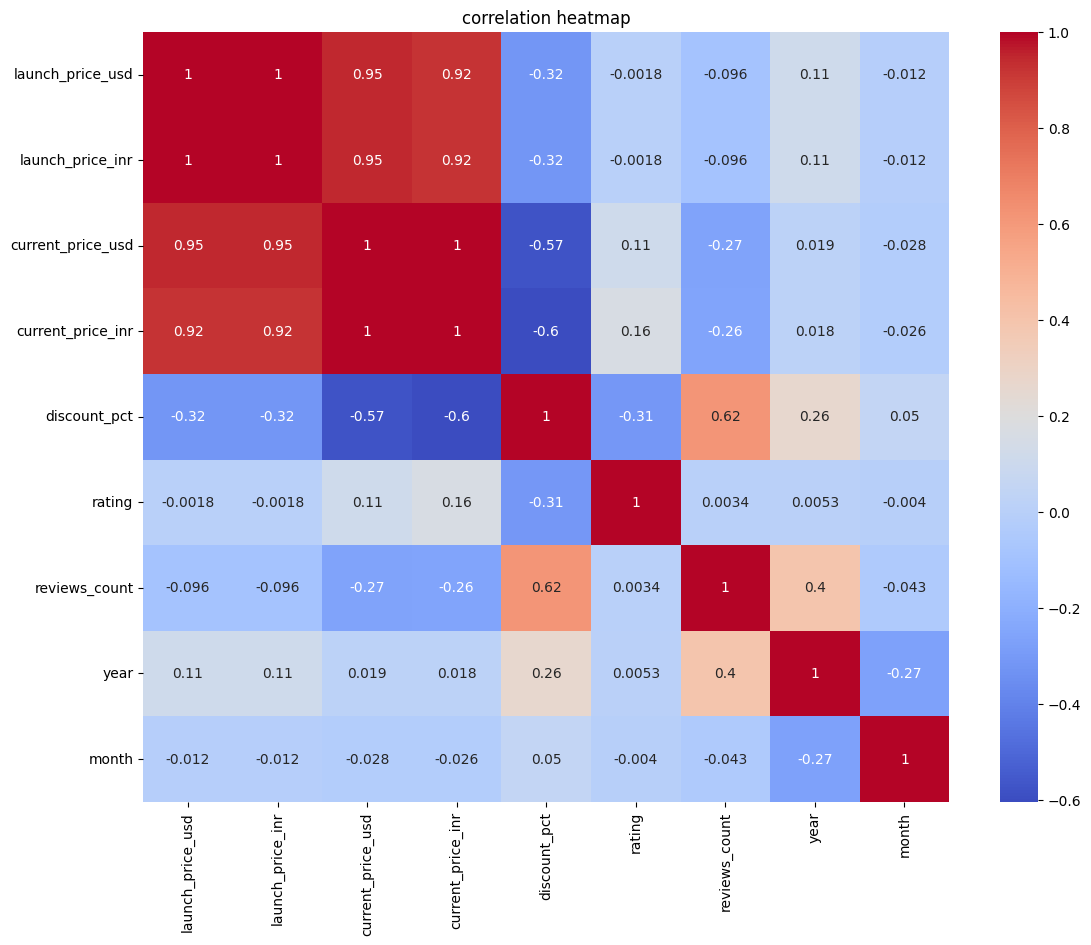

In [6]:
numeric_cols = df.select_dtypes(np.number)
plt.figure(figsize=(13,10))
sns.heatmap(numeric_cols.corr() , annot=True , cmap="coolwarm")
plt.title("correlation heatmap")
plt.show()

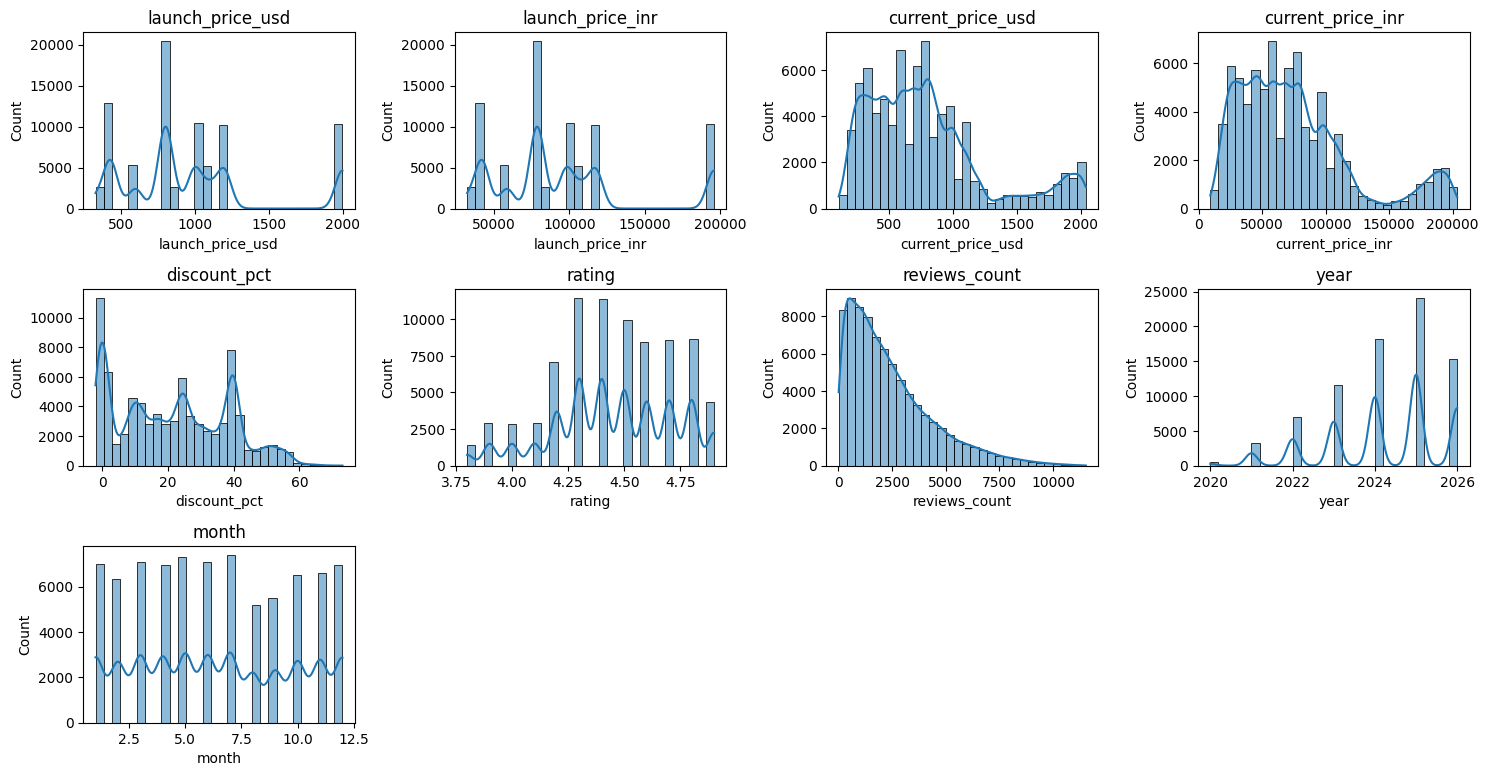

In [7]:
# distribution plot for numerical columns
numerical_cols = df.select_dtypes(include=["float64", "int64"]).columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i + 1) # adjust the number of rows and columns as needed
    sns.histplot(df[col], kde=True , bins = 30)
    plt.title(col)
plt.tight_layout()
plt.show()

# Phase 1 : Business overview & KPI

1 . What is the overall average selling price and average discount offered across all Apple products?

In [16]:
overall_price = pd.read_sql_query(text("""select round(avg(current_price_inr),2) as avg_price_current , round(avg(discount_pct),2) as avg_discount_offer from clean_dataset; """),engine)
display(overall_price)

,avg_price_current,avg_discount_offer
0,74628.34,21.42


2 . How does average price differ across product categories (iPhone, iPad, Mac, Watch)?


,product_category,avg_price_current
0,Mac,131766.94
1,iPhone,72370.86
2,iPad,54633.86
3,Watch,37983.28


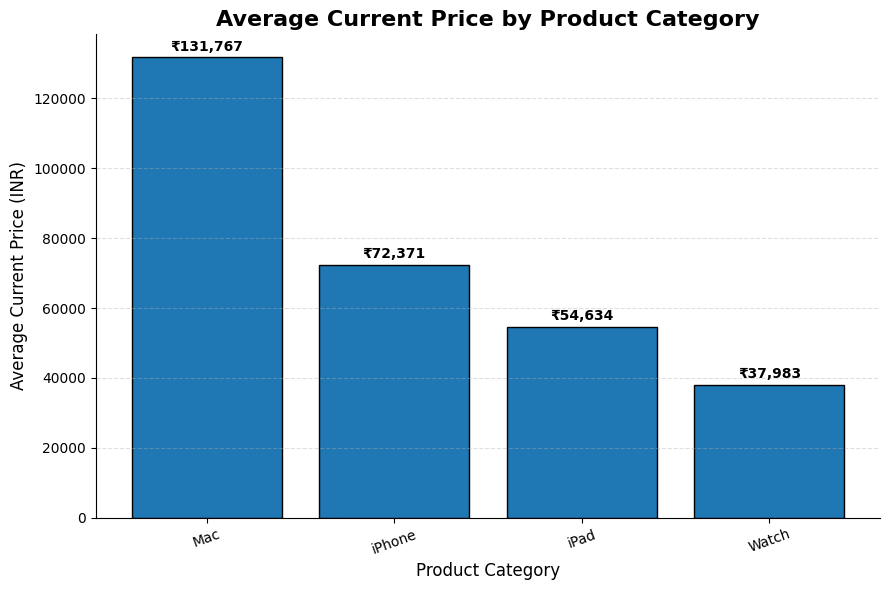

In [23]:
category_distribution = pd.read_sql_query(text("""select product_category , round(avg(current_price_inr),2) as avg_price_current from clean_dataset group by product_category order by avg_price_current desc"""),engine)
display(category_distribution)

plt.figure(figsize=(9,6))

bars = plt.bar(
    category_distribution["product_category"],
    category_distribution["avg_price_current"],
    edgecolor="black"
)

# Data labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1000,
        f"₹{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Average Current Price by Product Category",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Product Category", fontsize=12)
plt.ylabel("Average Current Price (INR)", fontsize=12)

plt.xticks(rotation=20)
plt.grid(axis="y", linestyle="--", alpha=0.4)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

3 . What is the total review volume and average rating across the entire catalog, and what does it suggest about customer engagement?

In [18]:
catalog = pd.read_sql_query(text("""select sum(reviews_count) as total_review , round(avg(rating),2) avg_rating from clean_dataset; """),engine)
display(catalog)

,total_review,avg_rating
0,192479674.0,4.45


**The high review volume + high average rating is a very positive signal.**
**It suggests that the catalog is not only popular but also well-received by customers.**


4 . Which product category contributes the most "market activity" (listings × reviews) and can be considered the business's core revenue driver?

,product_category,listing,total_review,market_activity
0,iPhone,28589,65187205.0,1.863637e+12
1,Watch,17865,42520463.0,7.596281e+11
2,Mac,18020,41174963.0,7.419728e+11
3,iPad,15526,43597043.0,6.768877e+11


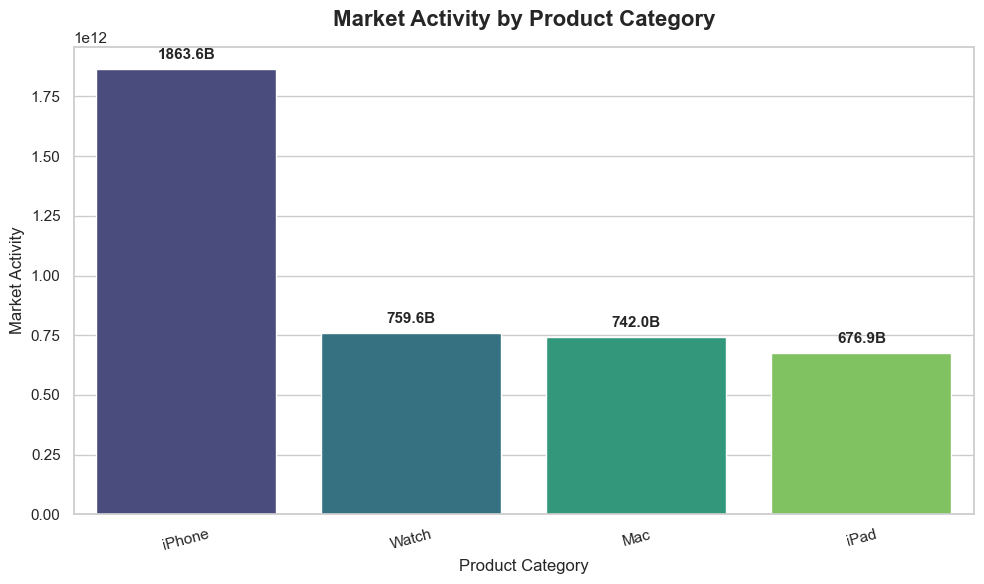

In [26]:
market_activity = pd.read_sql_query(text("""select product_category , count(*) as listing ,
sum(reviews_count) as total_review , round(count(*) * sum(reviews_count),2) as market_activity from clean_dataset group by product_category order by market_activity desc"""),engine)
display(market_activity)

# Set style
sns.set_theme(style="whitegrid")

# Create figure
plt.figure(figsize=(10,6))

# Bar plot
ax = sns.barplot(
    data=market_activity,
    x="product_category",
    y="market_activity",
    palette="viridis"
)

# Title & Labels
ax.set_title("Market Activity by Product Category", fontsize=16, weight='bold', pad=15)
ax.set_xlabel("Product Category", fontsize=12)
ax.set_ylabel("Market Activity", fontsize=12)

# Function to format large numbers
def format_number(num):
    if num >= 1_000_000_000:
        return f'{num/1_000_000_000:.1f}B'
    elif num >= 1_000_000:
        return f'{num/1_000_000:.1f}M'
    elif num >= 1_000:
        return f'{num/1_000:.1f}K'
    else:
        return f'{num:.0f}'

# Add data labels
for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(
        format_number(height),
        (bar.get_x() + bar.get_width()/2, height),
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold',
        xytext=(0,5),
        textcoords='offset points'
    )

# Rotate x-axis labels if needed
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

5 . How has the average discount percentage evolved from 2020 to 2026 — is Apple's pricing becoming more aggressive over time?

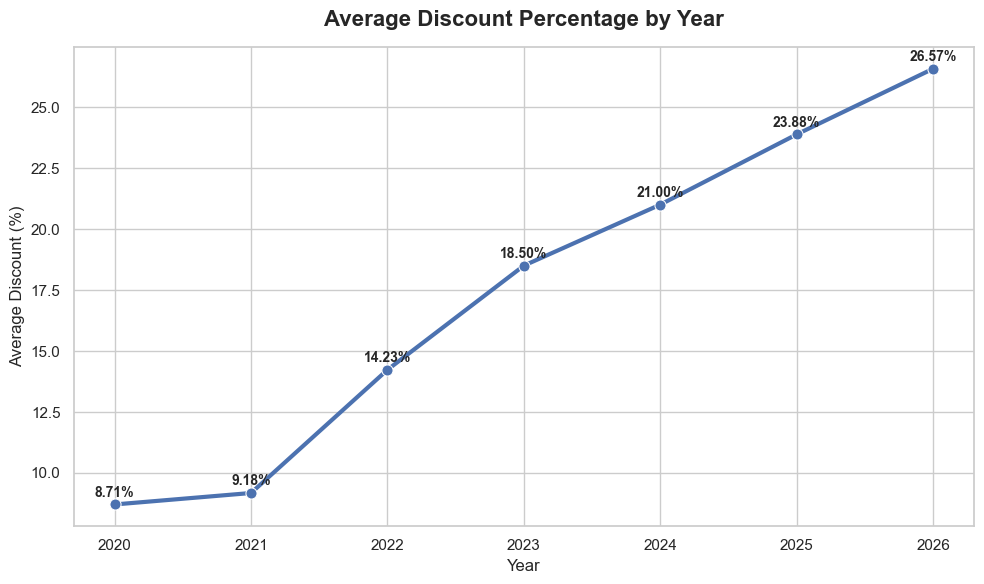

In [8]:
avg_discount = pd.read_sql_query(text("""select year , round(avg(discount_pct),2) as avg_discount from clean_dataset group by year"""),engine)
# display(avg_discount)


# Set style
sns.set_theme(style="whitegrid")

# Create figure
plt.figure(figsize=(10,6))

# Line chart
ax = sns.lineplot(
    data=avg_discount,
    x="year",
    y="avg_discount",
    marker="o",
    linewidth=3,
    markersize=8
)

# Title & Labels
ax.set_title("Average Discount Percentage by Year",
             fontsize=16,
             fontweight="bold",
             pad=15)

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Average Discount (%)", fontsize=12)

# Add data labels
for x, y in zip(avg_discount["year"], avg_discount["avg_discount"]):
    ax.text(
        x,
        y + 0.2,              # Slightly above the marker
        f"{y:.2f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# Improve layout
plt.xticks(avg_discount["year"])
plt.tight_layout()

plt.show()

# Phase 2 : product performance analysis

6 . Which specific Apple models have the highest customer engagement (reviews count) relative to their time in the market?

In [13]:
pd.read_sql_query(text("""SELECT 
    model_name,
    MIN(year) AS first_year,
    MAX(year) AS last_year,
    COUNT(DISTINCT year) AS years_active,
    SUM(reviews_count) AS total_reviews,
    ROUND(SUM(reviews_count) * 1.0 / COUNT(DISTINCT year), 0) AS avg_reviews_per_year
FROM clean_dataset
GROUP BY model_name
ORDER BY total_reviews DESC;"""),engine)

,model_name,first_year,last_year,years_active,total_reviews,avg_reviews_per_year
0,iPhone 12 Pro 128GB,2020,2026,7,9695181.0,1385026.0
1,iPad Air (4th Gen) 64GB,2020,2026,7,9610122.0,1372875.0
2,Apple Watch Series 6 (44mm),2020,2026,7,9432985.0,1347569.0
3,MacBook Air M1 256GB,2020,2026,7,9408082.0,1344012.0
4,iPhone 12 64GB,2020,2026,7,9281382.0,1325912.0
5,iPad Pro 11-inch (M1) 128GB,2021,2026,6,8765377.0,1460896.0
6,Apple Watch Series 7 (45mm),2021,2026,6,8006933.0,1334489.0
7,iPad (9th Gen) 64GB,2021,2026,6,7942664.0,1323777.0
8,iPhone 13 128GB,2021,2026,6,7922712.0,1320452.0
9,MacBook Pro 14-inch M1 Pro 512GB,2021,2026,6,7698954.0,1283159.0


7 . Which models sustain the highest ratings despite heavy discounting — indicating strong brand loyalty vs. price-sensitive demand?

In [29]:
pd.read_sql_query(text("""SELECT 
        model_name,
        ROUND(AVG(rating), 2) AS avg_rating_during_heavy_discount,
        ROUND(AVG(discount_pct), 2) AS avg_discount_pct,
        MIN(rating) AS lowest_rating_in_discount
    FROM clean_dataset
    WHERE discount_pct >= 20 
      AND reviews_count >= 50               
    GROUP BY model_name order by avg_rating_during_heavy_discount DESC
 """),engine)

,model_name,avg_rating_during_heavy_discount,avg_discount_pct,lowest_rating_in_discount
0,Apple Watch Series 6 (44mm),4.44,40.60,3.8
1,iPad (9th Gen) 64GB,4.44,40.98,3.8
2,Apple Watch Series 8 (45mm),4.44,37.97,3.8
3,iPhone 12 64GB,4.43,38.93,3.8
4,Apple Watch Series 7 (45mm),4.43,39.55,3.8
5,iPad Air (4th Gen) 64GB,4.42,41.15,3.8
6,iPhone 13 128GB,4.42,37.39,3.8
7,iPad Air (5th Gen) 64GB,4.42,39.91,3.8
8,Apple Watch Series 9 (45mm),4.42,35.43,3.8
9,iPhone 12 Pro 128GB,4.41,38.00,3.8


8 . Is there a relationship between a product's price tier and its review volume (do premium or budget models drive more engagement)?

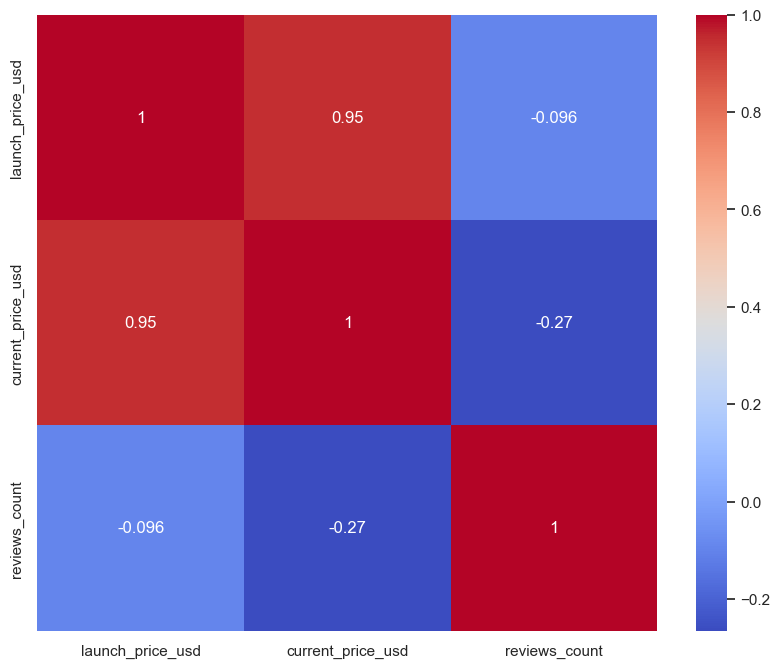

,mean,max,count
price_tier,,,
Budget (< $500),2567.52,11365,15401
Mid-range ($500–$999),2557.89,11526,38887
Premium ($1000+),2079.52,9510,25712


In [34]:
column_name = ['launch_price_usd' ,'current_price_usd','reviews_count']
plt.figure(figsize=(10, 8))
sns.heatmap(df[column_name].corr(), annot=True, cmap="coolwarm")
plt.show()

def get_price_tier(price):
    if price < 500:
        return 'Budget (< $500)'
    elif price < 1000:
        return 'Mid-range ($500–$999)'
    else:
        return 'Premium ($1000+)'

df['price_tier'] = df['launch_price_usd'].apply(get_price_tier)

tier_stats = df.groupby('price_tier')['reviews_count'].agg(
    mean='mean', max='max', count='count'
).round(2)

display(tier_stats)

**Budget and mid-range products drive ~23% more reviews on average than premium ones.**

9 . Which category (iPhone/iPad/Mac/Watch) shows the most price volatility over time, and what does that imply about demand stability?

,year,product_category,min_price,max_price,absolute_diffrence
0,2020,iPhone,40231.20,101732.0,61500.80
1,2020,Mac,52934.20,100952.0,48017.80
2,2020,iPad,28904.90,60915.6,32010.70
3,2020,Watch,21918.90,43429.3,21510.40
4,2021,Mac,50744.10,203260.0,152515.90
5,2021,iPhone,33615.10,121521.0,87905.90
6,2021,iPad,17547.40,81243.7,63696.30
7,2021,Watch,16503.20,43536.7,27033.50
8,2022,Mac,42273.40,202865.0,160591.60
9,2022,iPad,11258.40,121881.0,110622.60


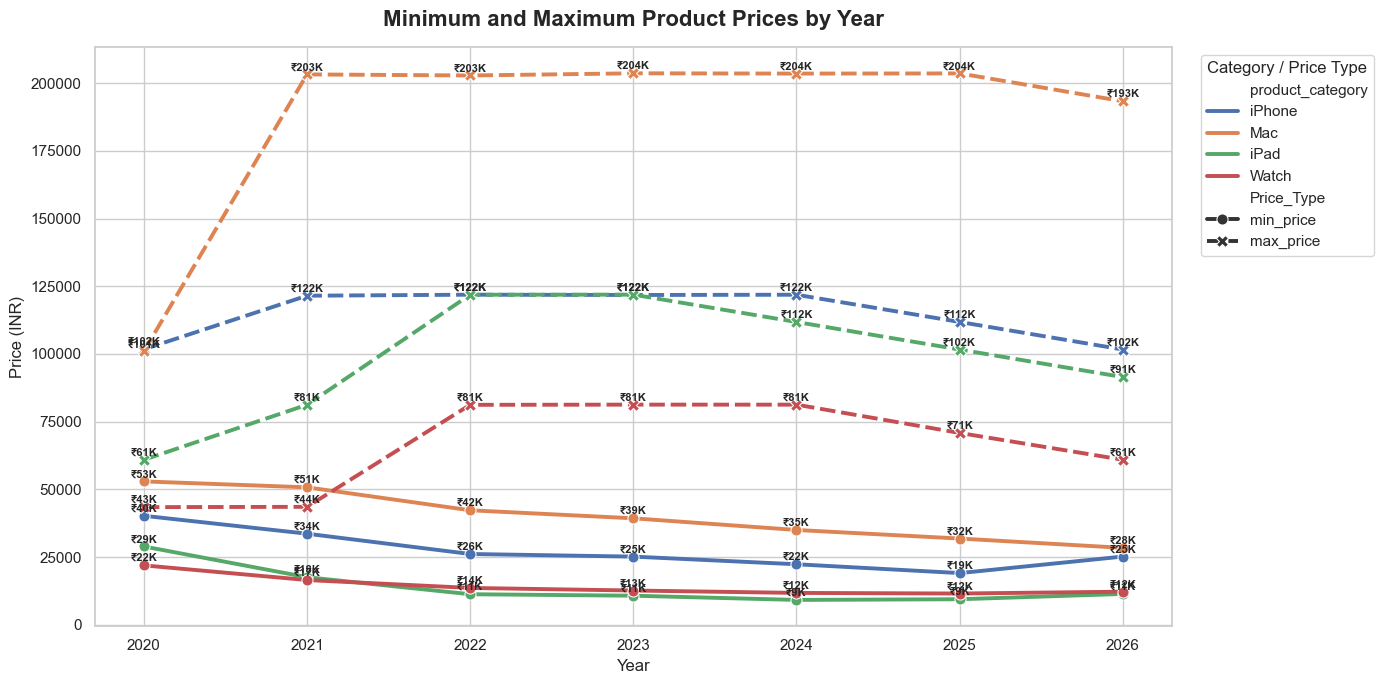

In [42]:
price_stability= pd.read_sql_query(text("""select year , product_category , min(current_price_inr) as min_price ,
max(current_price_inr) as max_price ,
ROUND(MAX(current_price_inr) - MIN(current_price_inr), 2) as absolute_diffrence 
from clean_dataset group by year , product_category
order by year , absolute_diffrence desc; """),engine)
display(price_stability)

# Set style
sns.set_theme(style="whitegrid")

# Create figure
plt.figure(figsize=(14,7))

# Convert wide format to long format
price_long = pd.melt(
    price_stability,
    id_vars=["year", "product_category"],
    value_vars=["min_price", "max_price"],
    var_name="Price_Type",
    value_name="Price"
)

# Line chart
ax = sns.lineplot(
    data=price_long,
    x="year",
    y="Price",
    hue="product_category",
    style="Price_Type",      # Different line styles for Min & Max
    markers=True,
    dashes=True,
    linewidth=2.8,
    markersize=8
)

# Title & Labels
ax.set_title(
    "Minimum and Maximum Product Prices by Year",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Price (INR)", fontsize=12)

# Function to format price labels
def format_price(value):
    if value >= 1_000_000:
        return f"₹{value/1_000_000:.1f}M"
    elif value >= 1_000:
        return f"₹{value/1_000:.0f}K"
    else:
        return f"₹{value:.0f}"

# Add data labels
for _, row in price_long.iterrows():
    ax.text(
        row["year"],
        row["Price"] + 1500,      # Adjust depending on your data
        format_price(row["Price"]),
        fontsize=8,
        ha="center",
        fontweight="bold"
    )

# Legend
plt.legend(
    title="Category / Price Type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


# Phase 3 : price & discount stretegy

10 . What is the average discount percentage by product category, and which category is discounted most aggressively?

In [47]:
avg_discount_category = pd.read_sql_query(text("""select product_category , round(AVG(discount_pct),2) as avg_discount_pct , count(*) as total_record , 
round(100.0 * count(*) / sum(count(*)) over(),2) as pct_of_total from clean_dataset group by product_category 
order by avg_discount_pct desc"""),engine)
display(avg_discount_category)

,product_category,avg_discount_pct,total_record,pct_of_total
0,Watch,26.27,17865,22.33
1,iPad,26.19,15526,19.41
2,iPhone,19.57,28589,35.74
3,Mac,15.43,18020,22.53


11 . How does discount depth vary by platform (Amazon vs Flipkart) for the same product category?

In [51]:
discount_depth = pd.read_sql_query(text("""select platform , product_category , round(avg(discount_pct),2) as avg_discount , min(discount_pct) as min_discount , max(discount_pct) as max_discount , count(*) as total_record from clean_dataset group by platform , product_category order by platform , product_category """),engine)
display(discount_depth)

,platform,product_category,avg_discount,min_discount,max_discount,total_record
0,Amazon,iPad,26.34,-2.0,67.6,7788
1,Amazon,iPhone,19.80,-2.0,69.9,14244
2,Amazon,Mac,15.52,-2.0,66.7,9083
3,Amazon,Watch,26.19,-2.0,66.5,8842
4,Flipkart,iPad,26.04,-2.0,66.8,7738
5,Flipkart,iPhone,19.35,-2.0,73.1,14345
6,Flipkart,Mac,15.34,-2.0,61.9,8937
7,Flipkart,Watch,26.34,-2.0,67.9,9023


12 . Which products show negative discount values (price increases above launch price), and what business scenarios could explain this (scalping, low stock, currency fluctuation)?

In [53]:
negetive_discount = pd.read_sql_query(text("""select product_category  from clean_dataset where discount_pct < 0 group by product_category """),engine)
display(negetive_discount)

,product_category
0,Watch
1,iPad
2,iPhone
3,Mac
